In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Importar yfinance para datos financieros
import yfinance as yf

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [35]:
# dataset reddit completo, para crear serie 2023-2024

jsonl_path = '../data/procesada/data-reddit-sentiment.jsonl'

print("Cargando datos originales...")
records = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            if 'created_at' in data:
                data['created_at'] = pd.to_datetime(data['created_at'])
            records.append(data)
        except Exception as e:
            print(f"Error en la línea: {e}")
            continue

df = pd.DataFrame(records)
print(f"✓ Cargados {len(df):,} registros")
print(f"  Shape: {df.shape}")
print(f"  Rango de fechas: {df['created_at'].min()} a {df['created_at'].max()}")

Cargando datos originales...
✓ Cargados 102,926 registros
  Shape: (102926, 24)
  Rango de fechas: 2020-01-18 15:21:17 a 2025-11-14 19:10:55


In [36]:
# verificar datos faltantes

# Verificar columnas críticas
print(" Verificación de columnas críticas:")
print(f"   'created_at' presente: {'created_at' in df.columns}")
print(f"   'sentiment_probs' presente: {'sentiment_probs' in df.columns}")

if 'created_at' in df.columns:
    nulos_created_at = df['created_at'].isna().sum()
    print(f"   Nulos en 'created_at': {nulos_created_at} ({nulos_created_at/len(df)*100:.2f}%)")

if 'sentiment_probs' in df.columns:
    nulos_sentiment_probs = df['sentiment_probs'].isna().sum()
    print(f"   Nulos en 'sentiment_probs': {nulos_sentiment_probs} ({nulos_sentiment_probs/len(df)*100:.2f}%)")
    
    # Verificar estructura de sentiment_probs
    print("\n2. Verificación de estructura de 'sentiment_probs':")
    tipos = df['sentiment_probs'].apply(type).value_counts()
    print(f"   Tipos de datos:")
    for tipo, count in tipos.items():
        print(f"      {tipo.__name__}: {count} ({count/len(df)*100:.2f}%)")
    
    # Verificar si los diccionarios tienen 'POS'
    if df['sentiment_probs'].notna().any():
        muestra_no_nula = df[df['sentiment_probs'].notna()]['sentiment_probs'].iloc[0]
        if isinstance(muestra_no_nula, dict):
            print(f"   Ejemplo de estructura: {list(muestra_no_nula.keys())}")
            
            # Contar cuántos tienen 'POS'
            tiene_pos = df['sentiment_probs'].apply(
                lambda x: isinstance(x, dict) and 'POS' in x if pd.notna(x) else False
            ).sum()
            print(f"   Registros con 'POS' en sentiment_probs: {tiene_pos} ({tiene_pos/len(df)*100:.2f}%)")

# Verificar por año
print("\n3. Verificación por año:")
if 'created_at' in df.columns:
    df['year'] = df['created_at'].dt.year
    for year in sorted(df['year'].dropna().unique()):
        df_year = df[df['year'] == year]
        nulos_year = df_year['sentiment_probs'].isna().sum() if 'sentiment_probs' in df.columns else 0
        print(f"   {year}: {len(df_year):,} registros, {nulos_year:,} sin sentiment_probs ({nulos_year/len(df_year)*100:.2f}%)")

# Resumen
print("\n4. Resumen:")
total_registros = len(df)
if 'created_at' in df.columns and 'sentiment_probs' in df.columns:
    registros_validos = df[
        df['created_at'].notna() & 
        df['sentiment_probs'].notna() &
        df['sentiment_probs'].apply(lambda x: isinstance(x, dict) and 'POS' in x if pd.notna(x) else False)
    ]
    print(f"   Total registros: {total_registros:,}")
    print(f"   Registros válidos (con created_at y POS en sentiment_probs): {len(registros_validos):,} ({len(registros_validos)/total_registros*100:.2f}%)")
    print(f"   Registros a descartar: {total_registros - len(registros_validos):,} ({(total_registros - len(registros_validos))/total_registros*100:.2f}%)")

 Verificación de columnas críticas:
   'created_at' presente: True
   'sentiment_probs' presente: True
   Nulos en 'created_at': 0 (0.00%)
   Nulos en 'sentiment_probs': 0 (0.00%)

2. Verificación de estructura de 'sentiment_probs':
   Tipos de datos:
      dict: 102926 (100.00%)
   Ejemplo de estructura: ['POS', 'NEG', 'NEU']
   Registros con 'POS' en sentiment_probs: 102926 (100.00%)

3. Verificación por año:
   2020: 24,236 registros, 0 sin sentiment_probs (0.00%)
   2021: 12,392 registros, 0 sin sentiment_probs (0.00%)
   2022: 16,453 registros, 0 sin sentiment_probs (0.00%)
   2023: 20,947 registros, 0 sin sentiment_probs (0.00%)
   2024: 28,641 registros, 0 sin sentiment_probs (0.00%)
   2025: 257 registros, 0 sin sentiment_probs (0.00%)

4. Resumen:
   Total registros: 102,926
   Registros válidos (con created_at y POS en sentiment_probs): 102,926 (100.00%)
   Registros a descartar: 0 (0.00%)


In [37]:


def extraer_pos_prob(x):
    """
    Extrae la probabilidad POS de sentiment_probs con verificación.
    Retorna None si no es válido.
    """
    if pd.isna(x):
        return None
    if isinstance(x, dict):
        return x.get('POS', None)
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            if isinstance(parsed, dict):
                return parsed.get('POS', None)
        except:
            return None
    return None

# Probar la función
print("Probando función de extracción...")
if 'sentiment_probs' in df.columns:
    muestra = df['sentiment_probs'].dropna().head(5)
    for idx, val in enumerate(muestra):
        pos_prob = extraer_pos_prob(val)
        print(f"   Muestra {idx+1}: {type(val).__name__} -> POS prob: {pos_prob}")

Probando función de extracción...
   Muestra 1: dict -> POS prob: 0.03119713068008423
   Muestra 2: dict -> POS prob: 0.008707097731530666
   Muestra 3: dict -> POS prob: 0.050372373312711716
   Muestra 4: dict -> POS prob: 0.007478612940758467
   Muestra 5: dict -> POS prob: 0.038220904767513275


In [38]:
# ============================================================================
# DATASET TRAIN 2023-2024
# ============================================================================

# Filtrar datos de 2023 y 2024
df_train = df[(df['created_at'].dt.year >= 2023) & (df['created_at'].dt.year <= 2024)].copy()

print(f"\n1. Filtrado por año:")
print(f"   Registros en 2023-2024: {len(df_train):,}")
print(f"   Rango: {df_train['created_at'].min()} a {df_train['created_at'].max()}")

# Extraer pos_prob con verificación
print(f"\n2. Extrayendo pos_prob...")
df_train_filtered = pd.DataFrame({
    'created_at': df_train['created_at'],
    'pos_prob': df_train['sentiment_probs'].apply(extraer_pos_prob)
})

# Estadísticas antes de eliminar nulos
nulos_antes = df_train_filtered['pos_prob'].isna().sum()
print(f"   Registros con pos_prob válido: {len(df_train_filtered) - nulos_antes:,}")
print(f"   Registros sin pos_prob: {nulos_antes:,} ({nulos_antes/len(df_train_filtered)*100:.2f}%)")

# Eliminar filas sin pos_prob
df_train_filtered = df_train_filtered.dropna(subset=['pos_prob'])
print(f"   Registros después de filtrar: {len(df_train_filtered):,}")

# Extraer fecha (solo día)
df_train_filtered['date'] = pd.to_datetime(df_train_filtered['created_at']).dt.date

# Agrupar por día y calcular media
print(f"\n3. Agrupando por día...")
df_train_diario = df_train_filtered.groupby('date')['pos_prob'].agg(['mean', 'count']).reset_index()
df_train_diario.columns = ['date', 'pos_prob_mean', 'count']
df_train_diario['date'] = pd.to_datetime(df_train_diario['date'])

print(f"   Días con datos: {len(df_train_diario)}")
print(f"   Promedio de registros por día: {df_train_diario['count'].mean():.1f}")

# Crear rango completo de fechas para 2023-2024
print(f"\n4. Creando rango completo de fechas...")
fecha_inicio_train = pd.Timestamp('2023-01-01')
fecha_fin_train = pd.Timestamp('2024-12-31')
rango_completo_train = pd.date_range(start=fecha_inicio_train, end=fecha_fin_train, freq='D')
df_rango_train = pd.DataFrame({'date': rango_completo_train})

print(f"   Total días en rango: {len(df_rango_train)}")

# Merge con datos existentes
df_train_completo = df_rango_train.merge(df_train_diario[['date', 'pos_prob_mean']], on='date', how='left')

# Obtener fecha actual (solo día, sin hora)
fecha_actual = pd.Timestamp.now().normalize()

# Identificar días sin datos (excluyendo días actuales y posteriores)
# Para 2023-2024, todos los días deberían estar en el pasado, así que verificamos todos
dias_sin_datos_train = df_train_completo['pos_prob_mean'].isna().sum()
dias_sin_datos_verificar = df_train_completo[df_train_completo['pos_prob_mean'].isna()].copy()

print(f"\n5. Verificación de días sin datos (2023-2024):")
print(f"   Días sin datos: {dias_sin_datos_train} ({dias_sin_datos_train/len(df_rango_train)*100:.2f}%)")
if len(dias_sin_datos_verificar) > 0:
    print(f"   Primeros 10 días sin datos:")
    print(dias_sin_datos_verificar[['date']].head(10).to_string(index=False))
    print(f"   Últimos 10 días sin datos:")
    print(dias_sin_datos_verificar[['date']].tail(10).to_string(index=False))

# Imputar valores faltantes (todos los días de 2023-2024 están en el pasado)
print(f"\n6. Imputando valores faltantes...")
df_train_completo['pos_prob_mean'] = df_train_completo['pos_prob_mean'].fillna(method='ffill').fillna(method='bfill')

if df_train_completo['pos_prob_mean'].isna().any():
    df_train_completo['pos_prob_mean'] = df_train_completo['pos_prob_mean'].interpolate(method='linear')
    
    if df_train_completo['pos_prob_mean'].isna().any():
        media_general = df_train_diario['pos_prob_mean'].mean()
        df_train_completo['pos_prob_mean'] = df_train_completo['pos_prob_mean'].fillna(media_general)
        print(f"   Usando media general como último recurso: {media_general:.4f}")

print(f"   Días imputados: {dias_sin_datos_train}")

# Guardar dataset de entrenamiento (temporalmente, antes de agregar datos financieros)
df_train_final = df_train_completo[['date', 'pos_prob_mean']].copy()
df_train_final['date'] = df_train_final['date'].dt.date

print(f"\n✓ Dataset de entrenamiento preparado (antes de agregar datos financieros)")
print(f"   Shape: {df_train_final.shape}")
print(f"   Estadísticas pos_prob_mean:")
print(f"      Media: {df_train_final['pos_prob_mean'].mean():.4f}")
print(f"      Std: {df_train_final['pos_prob_mean'].std():.4f}")
print(f"      Min: {df_train_final['pos_prob_mean'].min():.4f}")
print(f"      Max: {df_train_final['pos_prob_mean'].max():.4f}")


1. Filtrado por año:
   Registros en 2023-2024: 49,588
   Rango: 2023-01-01 17:08:21 a 2024-12-30 23:49:09

2. Extrayendo pos_prob...
   Registros con pos_prob válido: 49,588
   Registros sin pos_prob: 0 (0.00%)
   Registros después de filtrar: 49,588

3. Agrupando por día...
   Días con datos: 639
   Promedio de registros por día: 77.6

4. Creando rango completo de fechas...
   Total días en rango: 731

5. Verificación de días sin datos (2023-2024):
   Días sin datos: 92 (12.59%)
   Primeros 10 días sin datos:
      date
2023-01-03
2023-01-04
2023-01-11
2023-01-30
2023-01-31
2023-02-03
2023-02-04
2023-02-07
2023-02-11
2023-02-12
   Últimos 10 días sin datos:
      date
2024-07-30
2024-07-31
2024-08-01
2024-08-31
2024-09-01
2024-09-30
2024-10-18
2024-10-31
2024-11-30
2024-12-31

6. Imputando valores faltantes...
   Días imputados: 92

✓ Dataset de entrenamiento preparado (antes de agregar datos financieros)
   Shape: (731, 2)
   Estadísticas pos_prob_mean:
      Media: 0.1223
      St

In [39]:
# ============================================================================
# DATASET TEST 2025
# ============================================================================

# Cargar datos de 2025 (desde JSONL con sentimiento)
jsonl_2025_path = '../data/procesada/reddit_unified_2025_with_sentiment.jsonl'

print(f"\n1. Cargando datos de 2025...")
records_2025 = []
with open(jsonl_2025_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            if 'created_at' in data:
                data['created_at'] = pd.to_datetime(data['created_at'])
            records_2025.append(data)
        except Exception as e:
            print(f"   Error al procesar línea: {e}")
            continue

df_2025 = pd.DataFrame(records_2025)
print(f"   Registros cargados: {len(df_2025):,}")

# Verificar datos faltantes
print(f"\n2. Verificando datos faltantes...")
if 'created_at' in df_2025.columns:
    nulos_created_at_2025 = df_2025['created_at'].isna().sum()
    print(f"   Nulos en 'created_at': {nulos_created_at_2025} ({nulos_created_at_2025/len(df_2025)*100:.2f}%)")

if 'sentiment_probs' in df_2025.columns:
    nulos_sentiment_probs_2025 = df_2025['sentiment_probs'].isna().sum()
    print(f"   Nulos en 'sentiment_probs': {nulos_sentiment_probs_2025} ({nulos_sentiment_probs_2025/len(df_2025)*100:.2f}%)")

# Extraer pos_prob
print(f"\n3. Extrayendo pos_prob...")
df_2025_filtered = pd.DataFrame({
    'created_at': df_2025['created_at'],
    'pos_prob': df_2025['sentiment_probs'].apply(extraer_pos_prob)
})

nulos_antes_2025 = df_2025_filtered['pos_prob'].isna().sum()
print(f"   Registros con pos_prob válido: {len(df_2025_filtered) - nulos_antes_2025:,}")
print(f"   Registros sin pos_prob: {nulos_antes_2025:,} ({nulos_antes_2025/len(df_2025_filtered)*100:.2f}%)")

# Eliminar filas sin pos_prob
df_2025_filtered = df_2025_filtered.dropna(subset=['pos_prob'])
print(f"   Registros después de filtrar: {len(df_2025_filtered):,}")

# Extraer fecha (solo día)
df_2025_filtered['date'] = pd.to_datetime(df_2025_filtered['created_at']).dt.date

# Agrupar por día y calcular media
print(f"\n4. Agrupando por día...")
df_2025_diario = df_2025_filtered.groupby('date')['pos_prob'].agg(['mean', 'count']).reset_index()
df_2025_diario.columns = ['date', 'pos_prob_mean', 'count']
df_2025_diario['date'] = pd.to_datetime(df_2025_diario['date'])

print(f"   Días con datos: {len(df_2025_diario)}")
print(f"   Rango: {df_2025_diario['date'].min().date()} a {df_2025_diario['date'].max().date()}")
print(f"   Promedio de registros por día: {df_2025_diario['count'].mean():.1f}")

# Crear rango completo de fechas para 2025
print(f"\n5. Creando rango completo de fechas...")
fecha_inicio_2025 = pd.Timestamp('2025-01-01')
fecha_fin_2025 = pd.Timestamp('2025-12-31')
rango_completo_2025 = pd.date_range(start=fecha_inicio_2025, end=fecha_fin_2025, freq='D')
df_rango_2025 = pd.DataFrame({'date': rango_completo_2025})

print(f"   Total días en rango: {len(df_rango_2025)}")

# Obtener fecha actual (solo día, sin hora)
fecha_actual = pd.Timestamp.now().normalize()

# Merge con datos existentes
df_2025_completo = df_rango_2025.merge(df_2025_diario[['date', 'pos_prob_mean']], on='date', how='left')

# Identificar días sin datos (excluyendo días actuales y posteriores)
# Solo verificamos días que son anteriores o iguales a la fecha actual
dias_para_verificar = df_2025_completo[df_2025_completo['date'] <= fecha_actual]
dias_sin_datos_2025 = dias_para_verificar['pos_prob_mean'].isna().sum()
dias_sin_datos_verificar_2025 = dias_para_verificar[dias_para_verificar['pos_prob_mean'].isna()].copy()

# Días futuros (posteriores a hoy) - estos NO deben imputarse
dias_futuros = df_2025_completo[df_2025_completo['date'] > fecha_actual]
dias_futuros_sin_datos = dias_futuros['pos_prob_mean'].isna().sum()

print(f"\n6. Verificación de días sin datos (2025):")
print(f"   Fecha actual: {fecha_actual.date()}")
print(f"   Días hasta hoy sin datos: {dias_sin_datos_2025} (de {len(dias_para_verificar)} días hasta hoy)")
print(f"   Días futuros sin datos (NO se imputarán): {dias_futuros_sin_datos} (de {len(dias_futuros)} días futuros)")

if len(dias_sin_datos_verificar_2025) > 0:
    print(f"\n   Primeros 10 días sin datos (hasta hoy):")
    print(dias_sin_datos_verificar_2025[['date']].head(10).to_string(index=False))
    if len(dias_sin_datos_verificar_2025) > 10:
        print(f"   Últimos 10 días sin datos (hasta hoy):")
        print(dias_sin_datos_verificar_2025[['date']].tail(10).to_string(index=False))

# Imputar valores faltantes SOLO para días hasta la fecha actual
# Los días futuros se dejan como NaN
print(f"\n7. Imputando valores faltantes (solo días hasta hoy)...")

# Separar días pasados/presentes de días futuros
df_2025_pasado = df_2025_completo[df_2025_completo['date'] <= fecha_actual].copy()
df_2025_futuro = df_2025_completo[df_2025_completo['date'] > fecha_actual].copy()

# Imputar solo en días pasados/presentes
df_2025_pasado['pos_prob_mean'] = df_2025_pasado['pos_prob_mean'].fillna(method='ffill').fillna(method='bfill')

if df_2025_pasado['pos_prob_mean'].isna().any():
    df_2025_pasado['pos_prob_mean'] = df_2025_pasado['pos_prob_mean'].interpolate(method='linear')
    
    if df_2025_pasado['pos_prob_mean'].isna().any():
        media_general_2025 = df_2025_diario['pos_prob_mean'].mean()
        df_2025_pasado['pos_prob_mean'] = df_2025_pasado['pos_prob_mean'].fillna(media_general_2025)
        print(f"   Usando media general como último recurso: {media_general_2025:.4f}")

print(f"   Días imputados (hasta hoy): {dias_sin_datos_2025}")
print(f"   Días futuros sin imputar: {dias_futuros_sin_datos}")

# Combinar días pasados (con imputación) y días futuros (sin imputar)
df_2025_completo = pd.concat([df_2025_pasado, df_2025_futuro]).sort_values('date').reset_index(drop=True)

# Guardar dataset de test (temporalmente, antes de agregar datos financieros)
df_2025_final = df_2025_completo[['date', 'pos_prob_mean']].copy()
df_2025_final['date'] = df_2025_final['date'].dt.date

print(f"\n✓ Dataset de test preparado (antes de agregar datos financieros)")
print(f"   Shape: {df_2025_final.shape}")
print(f"   Días con datos (hasta hoy): {df_2025_pasado['pos_prob_mean'].notna().sum()}")
print(f"   Días sin datos (futuros, no imputados): {df_2025_futuro['pos_prob_mean'].isna().sum()}")
print(f"   Estadísticas pos_prob_mean (solo días con datos):")
datos_validos = df_2025_final[df_2025_final['pos_prob_mean'].notna()]
print(f"      Media: {datos_validos['pos_prob_mean'].mean():.4f}")
print(f"      Std: {datos_validos['pos_prob_mean'].std():.4f}")
print(f"      Min: {datos_validos['pos_prob_mean'].min():.4f}")
print(f"      Max: {datos_validos['pos_prob_mean'].max():.4f}")


1. Cargando datos de 2025...
   Registros cargados: 19,391

2. Verificando datos faltantes...
   Nulos en 'created_at': 0 (0.00%)
   Nulos en 'sentiment_probs': 0 (0.00%)

3. Extrayendo pos_prob...
   Registros con pos_prob válido: 19,391
   Registros sin pos_prob: 0 (0.00%)
   Registros después de filtrar: 19,391

4. Agrupando por día...
   Días con datos: 308
   Rango: 2025-01-05 a 2025-11-18
   Promedio de registros por día: 63.0

5. Creando rango completo de fechas...
   Total días en rango: 365

6. Verificación de días sin datos (2025):
   Fecha actual: 2025-11-23
   Días hasta hoy sin datos: 19 (de 327 días hasta hoy)
   Días futuros sin datos (NO se imputarán): 38 (de 38 días futuros)

   Primeros 10 días sin datos (hasta hoy):
      date
2025-01-01
2025-01-02
2025-01-03
2025-01-04
2025-01-31
2025-02-28
2025-03-31
2025-04-30
2025-05-31
2025-06-30
   Últimos 10 días sin datos (hasta hoy):
      date
2025-06-30
2025-07-31
2025-08-31
2025-09-30
2025-10-31
2025-11-19
2025-11-20
202

In [40]:
# ============================================================================
# CARGAR Y PROCESAR DATOS FINANCIEROS
# ============================================================================

print("\n" + "="*60)
print("CARGANDO DATOS FINANCIEROS")
print("="*60)

# 1. Descargar datos de MERVAL desde yfinance
print("\n1. Descargando datos de MERVAL desde yfinance...")
ticker_merval = "^MERV"
fecha_inicio_merval = "2023-01-01"
fecha_fin_merval = pd.Timestamp.now().strftime('%Y-%m-%d')

try:
    merval_data = yf.download(ticker_merval, start=fecha_inicio_merval, end=fecha_fin_merval, auto_adjust=True)
    
    # Manejar estructura de datos de yfinance
    if isinstance(merval_data, pd.Series):
        precios_merval = merval_data
    elif isinstance(merval_data, pd.DataFrame):
        if isinstance(merval_data.columns, pd.MultiIndex):
            precios_merval = merval_data["Close"]
            if isinstance(precios_merval, pd.DataFrame):
                precios_merval = precios_merval.iloc[:, 0]
        else:
            precios_merval = merval_data["Close"]
    
    # Asegurar que sea Series 1D
    if isinstance(precios_merval, pd.DataFrame):
        precios_merval = precios_merval.iloc[:, 0]
    
    # Calcular retorno logarítmico
    retornos_merval = np.log(precios_merval).diff().fillna(0)
    
    # Crear DataFrame con fecha y retorno
    df_merval = pd.DataFrame({
        'date': retornos_merval.index.date,
        'retorno_log_merval': retornos_merval.values
    })
    df_merval['date'] = pd.to_datetime(df_merval['date']).dt.date
    
    print(f"   ✓ Datos de MERVAL cargados: {len(df_merval)} días")
    print(f"   Rango: {df_merval['date'].min()} a {df_merval['date'].max()}")
    print(f"   Estadísticas retorno_log_merval:")
    print(f"      Media: {df_merval['retorno_log_merval'].mean():.6f}")
    print(f"      Std: {df_merval['retorno_log_merval'].std():.6f}")
    
except Exception as e:
    print(f"   ✗ Error al descargar datos de MERVAL: {e}")
    df_merval = pd.DataFrame(columns=['date', 'retorno_log_merval'])

# 2. Cargar datos del dólar desde CSV
print("\n2. Cargando datos del dólar desde CSV...")
dolar_csv_path = '../data/raw/Datos históricos USD_ARS.csv'

try:
    # Leer CSV con encoding apropiado
    df_dolar_raw = pd.read_csv(dolar_csv_path, encoding='utf-8')
    
    # Parsear fecha (formato DD.MM.YYYY)
    df_dolar_raw['Fecha'] = pd.to_datetime(df_dolar_raw['Fecha'], format='%d.%m.%Y', errors='coerce')
    
    # Parsear valor del dólar (formato "1.415,00" -> 1415.00)
    def parse_dolar_value(val):
        if pd.isna(val):
            return None
        # Convertir a string y limpiar
        val_str = str(val).replace('.', '').replace(',', '.')
        try:
            return float(val_str)
        except:
            return None
    
    df_dolar_raw['valor_dolar'] = df_dolar_raw['Último'].apply(parse_dolar_value)
    
    # Filtrar fechas válidas y valores válidos
    df_dolar = df_dolar_raw[df_dolar_raw['Fecha'].notna() & df_dolar_raw['valor_dolar'].notna()].copy()
    df_dolar = df_dolar[['Fecha', 'valor_dolar']].copy()
    df_dolar.columns = ['date', 'valor_dolar']
    df_dolar['date'] = pd.to_datetime(df_dolar['date']).dt.date
    
    # Ordenar por fecha
    df_dolar = df_dolar.sort_values('date').reset_index(drop=True)
    
    # Calcular retorno logarítmico
    df_dolar['retorno_log_dolar'] = np.log(df_dolar['valor_dolar']).diff().fillna(0)
    
    # Eliminar columna valor_dolar (solo mantener retorno)
    df_dolar = df_dolar[['date', 'retorno_log_dolar']].copy()
    
    print(f"   ✓ Datos del dólar cargados: {len(df_dolar)} días")
    print(f"   Rango: {df_dolar['date'].min()} a {df_dolar['date'].max()}")
    print(f"   Estadísticas retorno_log_dolar:")
    print(f"      Media: {df_dolar['retorno_log_dolar'].mean():.6f}")
    print(f"      Std: {df_dolar['retorno_log_dolar'].std():.6f}")
    
except Exception as e:
    print(f"   ✗ Error al cargar datos del dólar: {e}")
    import traceback
    traceback.print_exc()
    df_dolar = pd.DataFrame(columns=['date', 'retorno_log_dolar'])


[*********************100%***********************]  1 of 1 completed


CARGANDO DATOS FINANCIEROS

1. Descargando datos de MERVAL desde yfinance...
   ✓ Datos de MERVAL cargados: 707 días
   Rango: 2023-01-02 a 2025-11-21
   Estadísticas retorno_log_merval:
      Media: 0.003664
      Std: 0.031727

2. Cargando datos del dólar desde CSV...
   ✓ Datos del dólar cargados: 702 días
   Rango: 2023-01-02 a 2025-11-20
   Estadísticas retorno_log_dolar:
      Media: 0.002015
      Std: 0.020056


In [41]:
# ============================================================================
# DIAGNÓSTICO: Verificar días faltantes en datos financieros
# ============================================================================

print("\n" + "="*60)
print("DIAGNÓSTICO DE DATOS FINANCIEROS")
print("="*60)

# 1. Verificar datos de MERVAL
print("\n1. ANÁLISIS DE DATOS MERVAL:")
print(f"   Total días con datos: {len(df_merval)}")
print(f"   Rango: {df_merval['date'].min()} a {df_merval['date'].max()}")

# Crear rango completo de fechas para MERVAL
rango_merval = pd.date_range(start=df_merval['date'].min(), end=df_merval['date'].max(), freq='D')
df_rango_merval = pd.DataFrame({'date': pd.to_datetime(rango_merval).date})
dias_faltantes_merval = df_rango_merval.merge(df_merval, on='date', how='left')
dias_sin_merval = dias_faltantes_merval[dias_faltantes_merval['retorno_log_merval'].isna()]

print(f"   Días en rango completo: {len(df_rango_merval)}")
print(f"   Días sin datos: {len(dias_sin_merval)}")
print(f"   Porcentaje de cobertura: {(len(df_merval)/len(df_rango_merval)*100):.1f}%")

# Verificar si son fines de semana
if len(dias_sin_merval) > 0:
    dias_sin_merval['date_dt'] = pd.to_datetime(dias_sin_merval['date'])
    dias_sin_merval['dia_semana'] = dias_sin_merval['date_dt'].dt.day_name()
    print(f"\n   Distribución de días sin datos por día de semana:")
    print(dias_sin_merval['dia_semana'].value_counts())
    
    # Mostrar algunos ejemplos
    print(f"\n   Primeros 10 días sin datos:")
    print(dias_sin_merval[['date', 'dia_semana']].head(10).to_string(index=False))

# 2. Verificar datos del dólar
print("\n2. ANÁLISIS DE DATOS DÓLAR:")
print(f"   Total días con datos: {len(df_dolar)}")
print(f"   Rango: {df_dolar['date'].min()} a {df_dolar['date'].max()}")

# Crear rango completo de fechas para dólar
rango_dolar = pd.date_range(start=df_dolar['date'].min(), end=df_dolar['date'].max(), freq='D')
df_rango_dolar = pd.DataFrame({'date': pd.to_datetime(rango_dolar).date})
dias_faltantes_dolar = df_rango_dolar.merge(df_dolar, on='date', how='left')
dias_sin_dolar = dias_faltantes_dolar[dias_faltantes_dolar['retorno_log_dolar'].isna()]

print(f"   Días en rango completo: {len(df_rango_dolar)}")
print(f"   Días sin datos: {len(dias_sin_dolar)}")
print(f"   Porcentaje de cobertura: {(len(df_dolar)/len(df_rango_dolar)*100):.1f}%")

# Verificar si son fines de semana
if len(dias_sin_dolar) > 0:
    dias_sin_dolar['date_dt'] = pd.to_datetime(dias_sin_dolar['date'])
    dias_sin_dolar['dia_semana'] = dias_sin_dolar['date_dt'].dt.day_name()
    print(f"\n   Distribución de días sin datos por día de semana:")
    print(dias_sin_dolar['dia_semana'].value_counts())
    
    # Mostrar algunos ejemplos
    print(f"\n   Primeros 10 días sin datos:")
    print(dias_sin_dolar[['date', 'dia_semana']].head(10).to_string(index=False))

# 3. Verificar solapamiento entre datasets
print("\n3. VERIFICACIÓN DE SOLAPAMIENTO:")
print(f"   Días comunes entre MERVAL y dólar: {len(pd.merge(df_merval, df_dolar, on='date', how='inner'))}")
print(f"   Días solo en MERVAL: {len(pd.merge(df_merval, df_dolar, on='date', how='left_only'))}")
print(f"   Días solo en dólar: {len(pd.merge(df_merval, df_dolar, on='date', how='right_only'))}")

# 4. Verificar qué pasa con el merge al dataset de entrenamiento
print("\n4. VERIFICACIÓN DE MERGE CON DATASET DE ENTRENAMIENTO:")
print(f"   Días en dataset entrenamiento: {len(df_train_final)}")
print(f"   Días que coinciden con MERVAL: {len(pd.merge(df_train_final, df_merval, on='date', how='inner'))}")
print(f"   Días que coinciden con dólar: {len(pd.merge(df_train_final, df_dolar, on='date', how='inner'))}")

# Verificar días específicos sin datos después del merge
df_train_test = df_train_final.merge(df_merval, on='date', how='left')
dias_sin_merval_train = df_train_test[df_train_test['retorno_log_merval'].isna()]

if len(dias_sin_merval_train) > 0:
    print(f"\n   Días en dataset entrenamiento SIN datos de MERVAL: {len(dias_sin_merval_train)}")
    dias_sin_merval_train['date_dt'] = pd.to_datetime(dias_sin_merval_train['date'])
    dias_sin_merval_train['dia_semana'] = dias_sin_merval_train['date_dt'].dt.day_name()
    print(f"   Distribución por día de semana:")
    print(dias_sin_merval_train['dia_semana'].value_counts())
    print(f"\n   Primeros 10 días sin MERVAL:")
    print(dias_sin_merval_train[['date', 'dia_semana']].head(10).to_string(index=False))


DIAGNÓSTICO DE DATOS FINANCIEROS

1. ANÁLISIS DE DATOS MERVAL:
   Total días con datos: 707
   Rango: 2023-01-02 a 2025-11-21
   Días en rango completo: 1055
   Días sin datos: 348
   Porcentaje de cobertura: 67.0%

   Distribución de días sin datos por día de semana:
dia_semana
Saturday     150
Sunday       150
Monday        17
Friday        13
Tuesday        7
Thursday       6
Wednesday      5
Name: count, dtype: int64

   Primeros 10 días sin datos:
      date dia_semana
2023-01-07   Saturday
2023-01-08     Sunday
2023-01-14   Saturday
2023-01-15     Sunday
2023-01-21   Saturday
2023-01-22     Sunday
2023-01-28   Saturday
2023-01-29     Sunday
2023-02-04   Saturday
2023-02-05     Sunday

2. ANÁLISIS DE DATOS DÓLAR:
   Total días con datos: 702
   Rango: 2023-01-02 a 2025-11-20
   Días en rango completo: 1054
   Días sin datos: 352
   Porcentaje de cobertura: 66.6%

   Distribución de días sin datos por día de semana:
dia_semana
Saturday     150
Sunday       150
Monday        15
Fri

ValueError: do not recognize join method left_only

In [42]:
# ============================================================================
# AGREGAR DATOS FINANCIEROS A DATASET DE ENTRENAMIENTO (2023-2024)
# ============================================================================

print("\n" + "="*60)
print("AGREGANDO DATOS FINANCIEROS A DATASET DE ENTRENAMIENTO")
print("="*60)

# Convertir date a datetime para merge
df_train_final['date_dt'] = pd.to_datetime(df_train_final['date'])

# Merge con datos de MERVAL
print("\n1. Agregando datos de MERVAL...")
df_train_final = df_train_final.merge(
    df_merval,
    on='date',
    how='left'
)

# Verificar días sin datos de MERVAL
dias_sin_merval = df_train_final['retorno_log_merval'].isna().sum()
print(f"   Días con datos de MERVAL: {len(df_train_final) - dias_sin_merval}")
print(f"   Días sin datos de MERVAL (fines de semana/feriados): {dias_sin_merval}")
print(f"   NOTA: No se imputan - el modelo rellenará con 0 automáticamente")

# Merge con datos del dólar
print("\n2. Agregando datos del dólar...")
df_train_final = df_train_final.merge(
    df_dolar,
    on='date',
    how='left'
)

# Verificar días sin datos del dólar
dias_sin_dolar = df_train_final['retorno_log_dolar'].isna().sum()
print(f"   Días con datos del dólar: {len(df_train_final) - dias_sin_dolar}")
print(f"   Días sin datos del dólar (fines de semana/feriados): {dias_sin_dolar}")
print(f"   NOTA: No se imputan - el modelo rellenará con 0 automáticamente")

# 3. Crear columna 'prediccion' (target): 1 si MERVAL sube al día siguiente, 0 si baja
# El target debe ser NaN para días no hábiles (el modelo los filtrará automáticamente)
print("\n3. Creando columna 'prediccion' (target)...")

# Obtener retorno del día siguiente (shift -1 porque queremos predecir el futuro)
df_train_final['retorno_merval_siguiente'] = df_train_final['retorno_log_merval'].shift(-1)

# Crear target: 1 si sube, 0 si baja, NaN si no hay dato del día siguiente
df_train_final['prediccion'] = np.where(
    df_train_final['retorno_merval_siguiente'].notna(),
    (df_train_final['retorno_merval_siguiente'] > 0).astype(int),
    np.nan
)

# Eliminar columna temporal y auxiliar
df_train_final = df_train_final.drop(['date_dt', 'retorno_merval_siguiente'], axis=1)

# Reordenar columnas: features primero, target al final
df_train_final = df_train_final[['date', 'pos_prob_mean', 'retorno_log_merval', 'retorno_log_dolar', 'prediccion']]

# Verificar target
dias_con_target = df_train_final['prediccion'].notna().sum()
dias_sin_target = df_train_final['prediccion'].isna().sum()
print(f"   Días con target válido: {dias_con_target}")
print(f"   Días sin target (NaN - serán filtrados por el modelo): {dias_sin_target}")

# Guardar dataset de entrenamiento final (sin columna date para el modelo, separador ;)
df_train_final_sin_date = df_train_final.drop('date', axis=1)
df_train_final_sin_date.to_csv('../data/final/sentiment_train_2023_2024.csv', index=False, sep=';')

# También guardar con date para referencia
df_train_final.to_csv('../data/final/sentiment_train_2023_2024_with_date.csv', index=False)

print(f"\n✓ Dataset de entrenamiento FINAL guardado:")
print(f"   - sentiment_train_2023_2024.csv (sin 'date', formato para modelo, sep=';')")
print(f"   - sentiment_train_2023_2024_with_date.csv (con 'date', para referencia)")
print(f"   Shape: {df_train_final_sin_date.shape}")
print(f"   Columnas: {list(df_train_final_sin_date.columns)}")
print(f"\n   Estadísticas (solo días con datos):")
datos_validos = df_train_final[df_train_final['retorno_log_merval'].notna()]
print(f"      pos_prob_mean - Media: {datos_validos['pos_prob_mean'].mean():.4f}, Std: {datos_validos['pos_prob_mean'].std():.4f}")
print(f"      retorno_log_merval - Media: {datos_validos['retorno_log_merval'].mean():.6f}, Std: {datos_validos['retorno_log_merval'].std():.6f}")
print(f"      retorno_log_dolar - Media: {datos_validos['retorno_log_dolar'].mean():.6f}, Std: {datos_validos['retorno_log_dolar'].std():.6f}")
if 'prediccion' in df_train_final.columns:
    pred_counts = df_train_final['prediccion'].value_counts().to_dict()
    print(f"      prediccion - Distribución: {pred_counts}")



AGREGANDO DATOS FINANCIEROS A DATASET DE ENTRENAMIENTO

1. Agregando datos de MERVAL...
   Días con datos de MERVAL: 488
   Días sin datos de MERVAL (fines de semana/feriados): 243
   NOTA: No se imputan - el modelo rellenará con 0 automáticamente

2. Agregando datos del dólar...
   Días con datos del dólar: 485
   Días sin datos del dólar (fines de semana/feriados): 246
   NOTA: No se imputan - el modelo rellenará con 0 automáticamente

3. Creando columna 'prediccion' (target)...
   Días con target válido: 488
   Días sin target (NaN - serán filtrados por el modelo): 243

✓ Dataset de entrenamiento FINAL guardado:
   - sentiment_train_2023_2024.csv (sin 'date', formato para modelo, sep=';')
   - sentiment_train_2023_2024_with_date.csv (con 'date', para referencia)
   Shape: (731, 4)
   Columnas: ['pos_prob_mean', 'retorno_log_merval', 'retorno_log_dolar', 'prediccion']

   Estadísticas (solo días con datos):
      pos_prob_mean - Media: 0.1203, Std: 0.0854
      retorno_log_merval - 

# ============================================================================
# EXPLICACIÓN: CÓMO FUNCIONA EL MODELO LSTM
# ============================================================================

## 1. Manejo de días no hábiles (sábados, domingos, feriados)

El modelo LSTM usa `MaskedSeqDataset` (ver `src/modelo/model_utils.py` líneas 5-45) que:

- **Filtra automáticamente días donde el target es NaN**: Solo incluye en el entrenamiento días donde `y[i]` no es NaN (líneas 22-25)
- **No necesita imputación de target**: Los días no hábiles quedan como NaN y el modelo los ignora automáticamente
- **Features se rellenan con 0**: Si las features tienen NaN, el código del modelo las rellena con 0 (ver `training.py` línea 48)

## 2. Formato esperado del CSV

El modelo espera:
- **Separador**: `;` (punto y coma)
- **Columna target**: `prediccion` (0 o 1, o NaN para días no hábiles)
- **Features**: Todas las demás columnas (se normalizan automáticamente)

## 3. Cómo correr el modelo

### Entrenamiento con Cross-Validation:
```bash
cd src/modelo
python training.py
```

### Entrenamiento final (con todos los datos):
```bash
cd src/modelo
python train_final.py
```

### Optimización de hiperparámetros:
```bash
cd src/modelo
python optuna_search.py
```

### Predicción:
```bash
cd src/modelo
python predict.py
```

**NOTA**: Asegúrate de que los archivos CSV estén en `src/modelo/data/` con los nombres:
- `data_train.csv` (para entrenamiento)
- `data_test.csv` (para predicción)


In [ ]:
# ============================================================================
# AGREGAR DATOS FINANCIEROS A DATASET DE TEST (2025)
# ============================================================================

print("\n" + "="*60)
print("AGREGAR DATOS FINANCIEROS A DATASET DE TEST")
print("="*60)

# Obtener fecha actual
fecha_actual = pd.Timestamp.now().normalize().date()

# LIMPIAR: Eliminar columnas financieras si ya existen (de ejecuciones anteriores)
print("\nVerificación previa:")
print(f"   Columnas en df_2025_final ANTES de limpiar: {list(df_2025_final.columns)}")

# Eliminar columnas financieras si existen
columnas_a_eliminar = ['retorno_log_merval', 'retorno_log_dolar', 'date_dt']
for col in columnas_a_eliminar:
    if col in df_2025_final.columns:
        df_2025_final = df_2025_final.drop(col, axis=1)
        print(f"   Eliminada columna duplicada: {col}")

print(f"   Columnas en df_2025_final DESPUÉS de limpiar: {list(df_2025_final.columns)}")

# Verificar que df_merval y df_dolar tienen las columnas esperadas
print(f"\n   Columnas en df_merval: {list(df_merval.columns)}")
print(f"   Columnas en df_dolar: {list(df_dolar.columns)}")

# Asegurar que las fechas sean del mismo tipo
df_2025_final['date'] = pd.to_datetime(df_2025_final['date']).dt.date
df_merval['date'] = pd.to_datetime(df_merval['date']).dt.date
df_dolar['date'] = pd.to_datetime(df_dolar['date']).dt.date

# Merge con datos de MERVAL
print("\n1. Agregando datos de MERVAL...")
df_2025_final = df_2025_final.merge(
    df_merval,
    on='date',
    how='left'
)

print(f"   Columnas después de merge con MERVAL: {list(df_2025_final.columns)}")

# Verificar días sin datos de MERVAL (solo hasta hoy)
df_2025_hasta_hoy = df_2025_final[df_2025_final['date'] <= fecha_actual].copy()
dias_sin_merval_2025 = df_2025_hasta_hoy['retorno_log_merval'].isna().sum()
print(f"   Días con datos de MERVAL (hasta hoy): {len(df_2025_hasta_hoy) - dias_sin_merval_2025}")
print(f"   Días sin datos de MERVAL (hasta hoy, fines de semana/feriados): {dias_sin_merval_2025}")
print(f"   NOTA: No se imputan - el modelo rellenará con 0 automáticamente")

# Merge con datos del dólar
print("\n2. Agregando datos del dólar...")
df_2025_final = df_2025_final.merge(
    df_dolar,
    on='date',
    how='left'
)

print(f"   Columnas después de merge con dólar: {list(df_2025_final.columns)}")

# Verificar si la columna se agregó
if 'retorno_log_dolar' not in df_2025_final.columns:
    print("   ERROR: La columna 'retorno_log_dolar' no se agregó después del merge")
    print(f"   Columnas disponibles: {list(df_2025_final.columns)}")
    raise KeyError("La columna 'retorno_log_dolar' no existe después del merge")

# RECALCULAR df_2025_hasta_hoy después del merge con dólar
df_2025_hasta_hoy = df_2025_final[df_2025_final['date'] <= fecha_actual].copy()

# Verificar días sin datos del dólar (solo hasta hoy)
dias_sin_dolar_2025 = df_2025_hasta_hoy['retorno_log_dolar'].isna().sum()
print(f"   Días con datos del dólar (hasta hoy): {len(df_2025_hasta_hoy) - dias_sin_dolar_2025}")
print(f"   Días sin datos del dólar (hasta hoy, fines de semana/feriados): {dias_sin_dolar_2025}")
print(f"   NOTA: No se imputan - el modelo rellenará con 0 automáticamente")

# Eliminar columna temporal si existe
if 'date_dt' in df_2025_final.columns:
    df_2025_final = df_2025_final.drop('date_dt', axis=1)

# Para test, no necesitamos columna 'prediccion' (solo hacemos predicciones)
# Reordenar columnas (sin 'prediccion' porque es para test)
columnas_esperadas = ['date', 'pos_prob_mean', 'retorno_log_merval', 'retorno_log_dolar']
columnas_faltantes = [col for col in columnas_esperadas if col not in df_2025_final.columns]

if columnas_faltantes:
    print(f"   ADVERTENCIA: Faltan columnas: {columnas_faltantes}")
    print(f"   Columnas disponibles: {list(df_2025_final.columns)}")
else:
    # Reordenar columnas
    df_2025_final = df_2025_final[columnas_esperadas]

# Guardar dataset de test final (sin columna date para el modelo, separador ;)
df_2025_final_sin_date = df_2025_final.drop('date', axis=1)
df_2025_final_sin_date.to_csv('../data/final/sentiment_test_2025.csv', index=False, sep=';')

# También guardar con date para referencia
df_2025_final.to_csv('../data/final/sentiment_test_2025_with_date.csv', index=False)

print(f"\n✓ Dataset de test FINAL guardado:")
print(f"   - sentiment_test_2025.csv (sin 'date', formato para modelo, sep=';')")
print(f"   - sentiment_test_2025_with_date.csv (con 'date', para referencia)")
print(f"   Shape: {df_2025_final_sin_date.shape}")
print(f"   Columnas: {list(df_2025_final_sin_date.columns)}")
print(f"\n   Estadísticas (solo días con datos hasta hoy):")
datos_validos_2025 = df_2025_final[df_2025_final['pos_prob_mean'].notna()]
print(f"      pos_prob_mean - Media: {datos_validos_2025['pos_prob_mean'].mean():.4f}, Std: {datos_validos_2025['pos_prob_mean'].std():.4f}")
if 'retorno_log_merval' in datos_validos_2025.columns:
    datos_merval = datos_validos_2025[datos_validos_2025['retorno_log_merval'].notna()]
    if len(datos_merval) > 0:
        print(f"      retorno_log_merval - Media: {datos_merval['retorno_log_merval'].mean():.6f}, Std: {datos_merval['retorno_log_merval'].std():.6f}")
if 'retorno_log_dolar' in datos_validos_2025.columns:
    datos_dolar = datos_validos_2025[datos_validos_2025['retorno_log_dolar'].notna()]
    if len(datos_dolar) > 0:
        print(f"      retorno_log_dolar - Media: {datos_dolar['retorno_log_dolar'].mean():.6f}, Std: {datos_dolar['retorno_log_dolar'].std():.6f}")



AGREGAR DATOS FINANCIEROS A DATASET DE TEST

Verificación previa:
   Columnas en df_2025_final ANTES de limpiar: ['date', 'pos_prob_mean', 'date_dt', 'retorno_log_merval_x', 'retorno_log_dolar_x', 'retorno_log_merval_y', 'retorno_log_merval', 'retorno_log_dolar_y']
   Eliminada columna duplicada: retorno_log_merval
   Eliminada columna duplicada: date_dt
   Columnas en df_2025_final DESPUÉS de limpiar: ['date', 'pos_prob_mean', 'retorno_log_merval_x', 'retorno_log_dolar_x', 'retorno_log_merval_y', 'retorno_log_dolar_y']

   Columnas en df_merval: ['date', 'retorno_log_merval']
   Columnas en df_dolar: ['date', 'retorno_log_dolar']

1. Agregando datos de MERVAL...
   Columnas después de merge con MERVAL: ['date', 'pos_prob_mean', 'retorno_log_merval_x', 'retorno_log_dolar_x', 'retorno_log_merval_y', 'retorno_log_dolar_y', 'retorno_log_merval']
   Días con datos de MERVAL (hasta hoy): 219
   Días sin datos de MERVAL (hasta hoy): 108
   Días imputados (hasta hoy): 108

2. Agregando datos

In [ ]:
# ============================================================================
# PREPARAR ARCHIVOS PARA EL MODELO
# ============================================================================

import shutil
from pathlib import Path

print("\n" + "="*60)
print("PREPARANDO ARCHIVOS PARA EL MODELO LSTM")
print("="*60)

# Crear directorio data en src/modelo si no existe
modelo_data_dir = Path('../src/modelo/data')
modelo_data_dir.mkdir(parents=True, exist_ok=True)

# Copiar archivos al directorio del modelo
archivo_train = Path('../data/final/sentiment_train_2023_2024.csv')
archivo_test = Path('../data/final/sentiment_test_2025.csv')
destino_train = modelo_data_dir / 'data_train.csv'
destino_test = modelo_data_dir / 'data_test.csv'

if archivo_train.exists():
    shutil.copy(archivo_train, destino_train)
    print(f"✓ Archivo de entrenamiento copiado:")
    print(f"   {archivo_train} -> {destino_train}")
else:
    print(f"✗ No se encontró: {archivo_train}")

if archivo_test.exists():
    shutil.copy(archivo_test, destino_test)
    print(f"✓ Archivo de test copiado:")
    print(f"   {archivo_test} -> {destino_test}")
else:
    print(f"✗ No se encontró: {archivo_test}")

print(f"\n✓ Archivos listos en: {modelo_data_dir}")
print(f"\nAhora puedes ejecutar el modelo:")
print(f"   cd src/modelo")
print(f"   python training.py      # Cross-validation")
print(f"   python train_final.py  # Entrenamiento final")
print(f"   python predict.py      # Predicciones")



Dataset de ENTRENAMIENTO (2023-2024):
   Archivo: sentiment_train_2023_2024.csv
   Filas: 731
   Columnas: ['date', 'pos_prob_mean', 'date_dt']
   Rango: 2023-01-01 a 2024-12-31

Dataset de TEST (2025):
   Archivo: sentiment_test_2025.csv
   Filas: 365
   Columnas: ['date', 'pos_prob_mean']
   Rango: 2025-01-01 a 2025-12-31


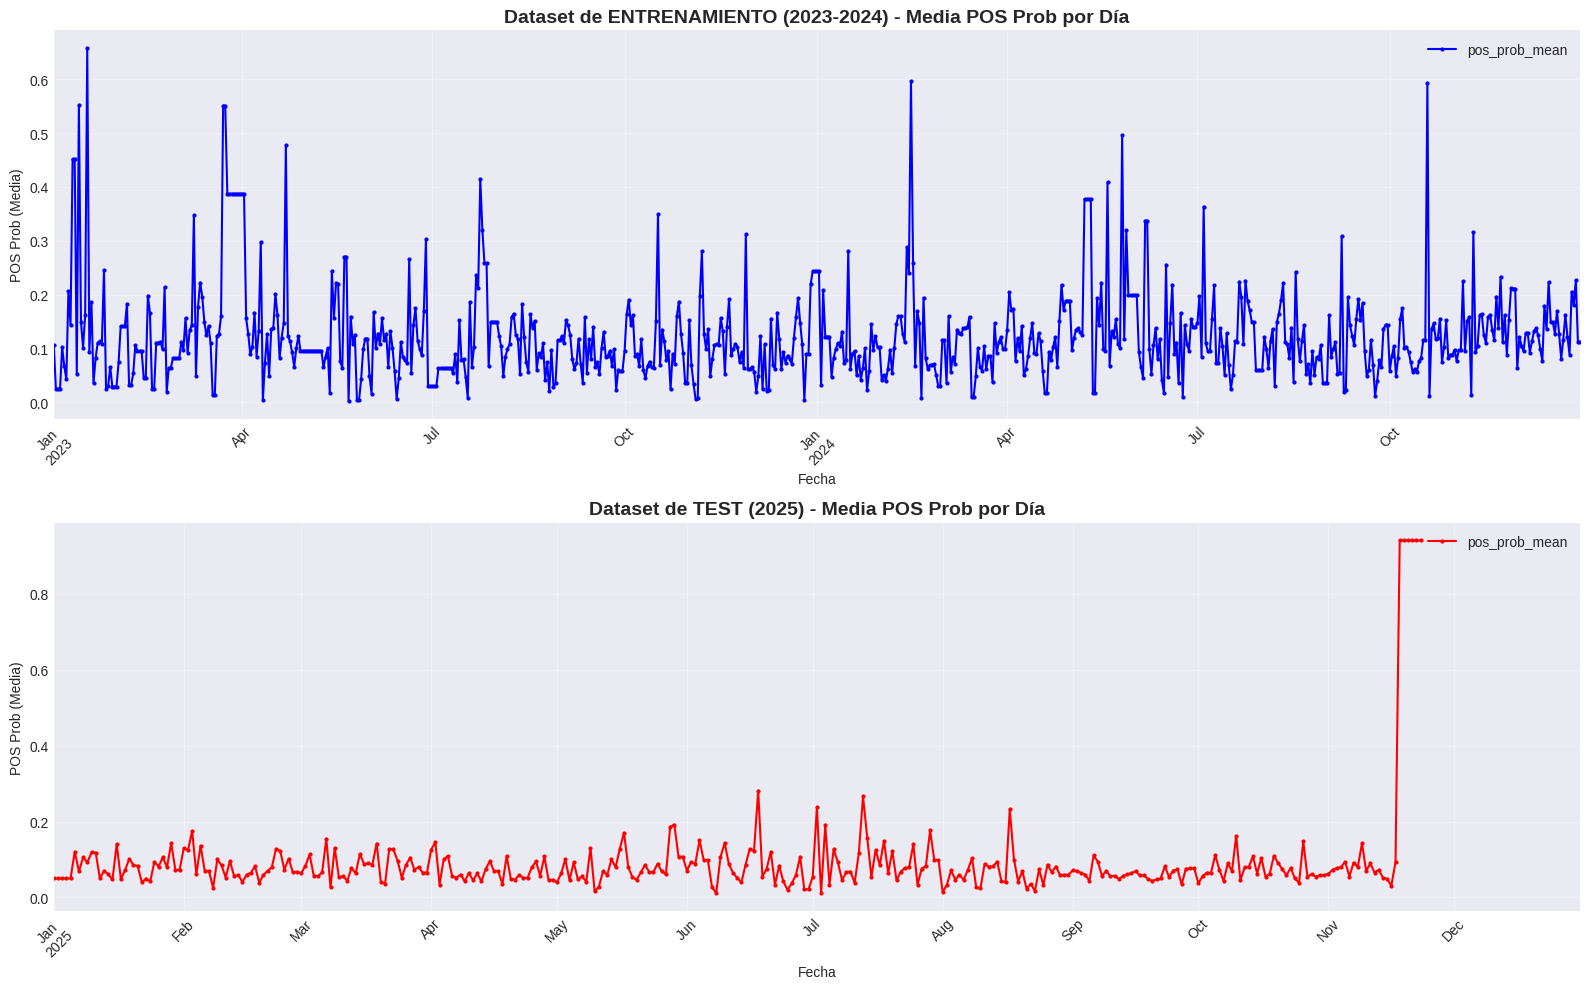

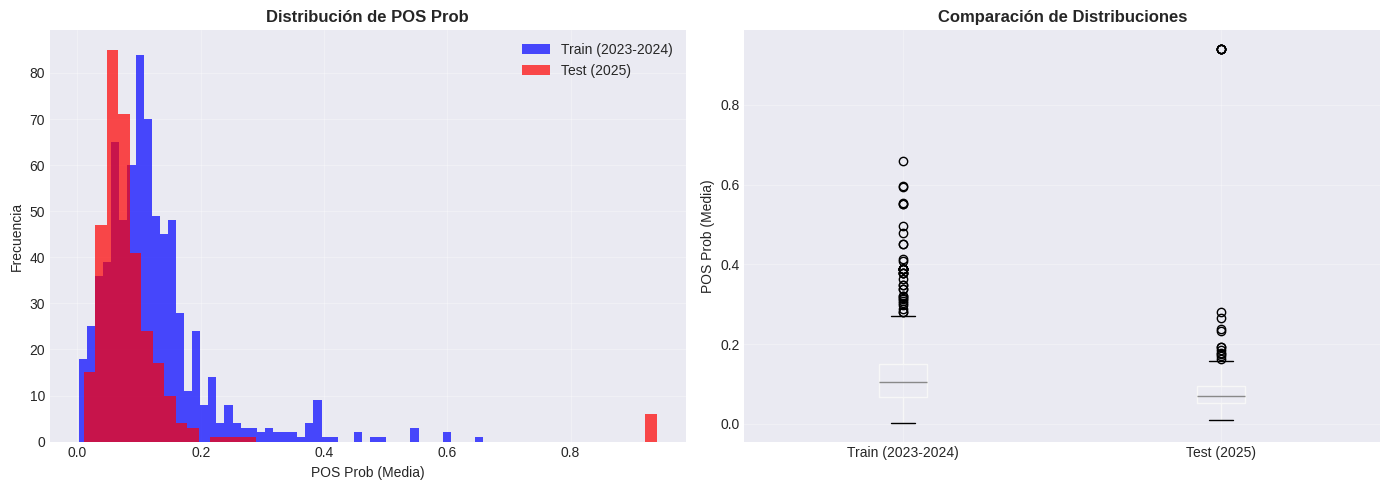


✓ Proceso completado exitosamente


In [ ]:

print(f"\nDataset de ENTRENAMIENTO (2023-2024):")
print(f"   Archivo: sentiment_train_2023_2024.csv")
print(f"   Filas: {len(df_train_final)}")
print(f"   Columnas: {list(df_train_final.columns)}")
print(f"   Rango: {df_train_final['date'].min()} a {df_train_final['date'].max()}")

print(f"\nDataset de TEST (2025):")
print(f"   Archivo: sentiment_test_2025.csv")
print(f"   Filas: {len(df_2025_final)}")
print(f"   Columnas: {list(df_2025_final.columns)}")
print(f"   Rango: {df_2025_final['date'].min()} a {df_2025_final['date'].max()}")

# Visualización comparativa
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Dataset de entrenamiento
df_train_final['date_dt'] = pd.to_datetime(df_train_final['date'])
df_train_final.plot(x='date_dt', y='pos_prob_mean', kind='line', ax=axes[0], 
                   color='blue', linewidth=1.5, marker='o', markersize=2)
axes[0].set_title('Dataset de ENTRENAMIENTO (2023-2024) - Media POS Prob por Día', 
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('POS Prob (Media)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Dataset de test
df_2025_final['date_dt'] = pd.to_datetime(df_2025_final['date'])
df_2025_final.plot(x='date_dt', y='pos_prob_mean', kind='line', ax=axes[1], 
                 color='red', linewidth=1.5, marker='o', markersize=2)
axes[1].set_title('Dataset de TEST (2025) - Media POS Prob por Día', 
                 fontweight='bold', fontsize=14)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('POS Prob (Media)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Comparación de distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas
axes[0].hist(df_train_final['pos_prob_mean'], bins=50, alpha=0.7, label='Train (2023-2024)', color='blue')
axes[0].hist(df_2025_final['pos_prob_mean'], bins=50, alpha=0.7, label='Test (2025)', color='red')
axes[0].set_title('Distribución de POS Prob', fontweight='bold')
axes[0].set_xlabel('POS Prob (Media)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plots
data_comparison = pd.DataFrame({
    'Train (2023-2024)': df_train_final['pos_prob_mean'],
    'Test (2025)': df_2025_final['pos_prob_mean']
})
data_comparison.boxplot(ax=axes[1])
axes[1].set_title('Comparación de Distribuciones', fontweight='bold')
axes[1].set_ylabel('POS Prob (Media)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Proceso completado exitosamente")